In [10]:
from pathlib import Path
import pandas as pd
import librosa
from IPython.display import Audio, display


# Project root
PROJECT_ROOT = Path.cwd().parent


# Load metadata
metadata_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "timit_metadata.csv"
)

df = pd.read_csv(metadata_path)

print("\nDataset shape:", df.shape)


# Select sample
sample = df.iloc[0]

print("\nSpeaker:", sample["speaker_id"])
print("Dialect:", sample["dialect"])
print("Transcript:", sample["transcript"])


# Build audio path
audio_path = PROJECT_ROOT / sample["audio_path"]


# Load audio
audio, sr = librosa.load(
    audio_path,
    sr=None,
    mono=True
)

print("\nSample rate:", sr)
print("Duration:", len(audio) / sr)


# Play
display(Audio(audio, rate=sr))


Dataset shape: (6300, 8)

Speaker: FBCG1
Dialect: DR8
Transcript: She had your dark suit in greasy wash water all year.

Sample rate: 16000
Duration: 3.09125


In [13]:
from IPython.display import Audio, display
import librosa

sample_indices = [0, 100, 500, 1000, 3000]

for i in sample_indices:

    sample = df.iloc[i]

    audio_path = PROJECT_ROOT / sample["audio_path"]

    audio, sr = librosa.load(
        audio_path,
        sr=None,
        mono=True
    )

    print("=" * 70)
    print("Speaker:", sample["speaker_id"])
    print("Dialect:", sample["dialect"])
    print("Split:", sample["split"])
    print("Utterance:", sample["utterance_id"])
    print("Transcript:", sample["transcript"])
    print("Duration:", round(sample["duration"], 2), "seconds")
    
    display(Audio(audio, rate=sr))

Speaker: FBCG1
Dialect: DR8
Split: train
Utterance: SA1
Transcript: She had your dark suit in greasy wash water all year.
Duration: 3.09 seconds


Speaker: MCXM0
Dialect: DR8
Split: train
Utterance: SA1
Transcript: She had your dark suit in greasy wash water all year.
Duration: 3.08 seconds


Speaker: MCTH0
Dialect: DR7
Split: train
Utterance: SA1
Transcript: She had your dark suit in greasy wash water all year.
Duration: 3.36 seconds


Speaker: FBCH0
Dialect: DR6
Split: train
Utterance: SA1
Transcript: She had your dark suit in greasy wash water all year.
Duration: 3.65 seconds


Speaker: MCEF0
Dialect: DR3
Split: train
Utterance: SA1
Transcript: She had your dark suit in greasy wash water all year.
Duration: 3.36 seconds


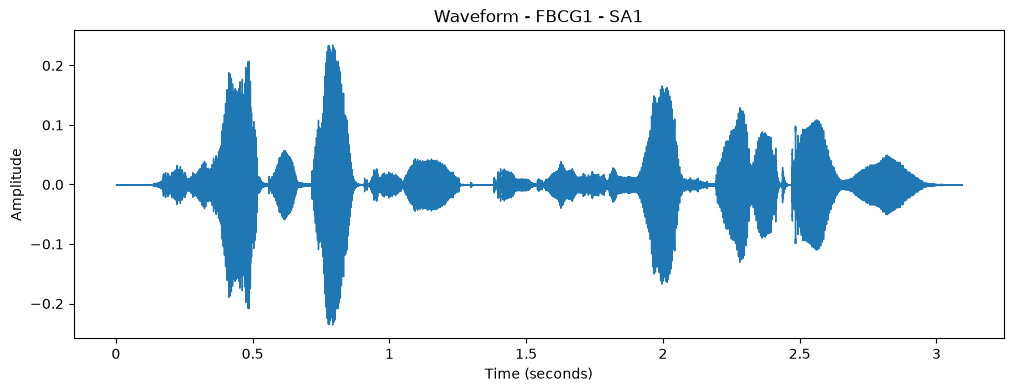

In [16]:
import matplotlib.pyplot as plt
import librosa.display

sample = df.iloc[0]

audio_path = PROJECT_ROOT / sample["audio_path"]

audio, sr = librosa.load(
    audio_path,
    sr=None,
    mono=True
)

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title(
    f"Waveform - {sample['speaker_id']} - {sample['utterance_id']}"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

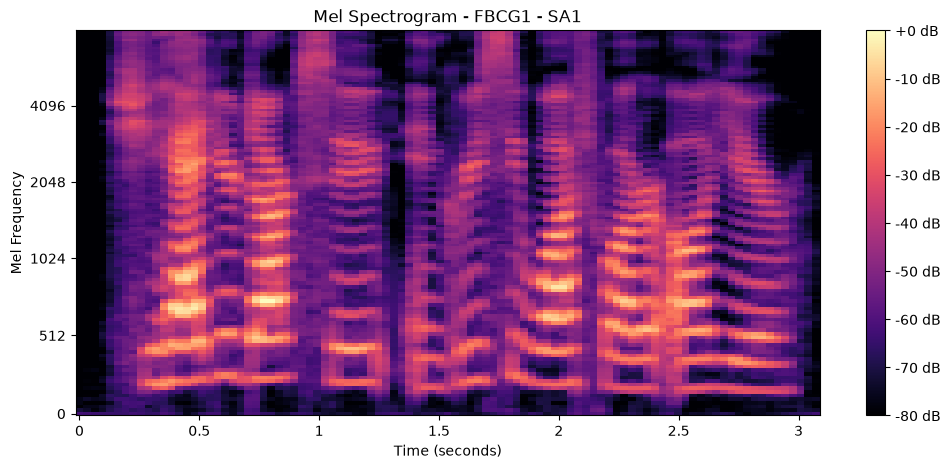

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

sample = df.iloc[0]

audio_path = PROJECT_ROOT / sample["audio_path"]

audio, sr = librosa.load(
    audio_path,
    sr=None,
    mono=True
)

# Create Mel spectrogram
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

# Convert power to decibels
mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

# Plot
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title(
    f"Mel Spectrogram - {sample['speaker_id']} - {sample['utterance_id']}"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")

plt.show()